# EDA for Price Model

*Is there a time of year when we get the best prices on the items we buy most often, and what should we be thinking about when we decide what to purchase when?*

In [1]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


DATA_DIR = os.environ.get("DATA_DIR", "../data")
conn = duckdb.connect(f"{DATA_DIR}/warehouse.duckdb", read_only=True)

In [2]:
conn.sql(
"""
SELECT *
FROM silver.item_pricing
LIMIT 5
""")

┌──────────┬───────────┬──────────────────────┬───────────────┐
│ item_id  │ vendor_id │ price_effective_date │ vendor_price  │
│ varchar  │  varchar  │         date         │ decimal(12,2) │
├──────────┼───────────┼──────────────────────┼───────────────┤
│ ITM-0256 │ VEND-05   │ 2025-08-19           │          2.93 │
│ ITM-0226 │ VEND-01   │ 2024-12-23           │          2.88 │
│ ITM-0726 │ VEND-10   │ 2024-04-04           │         56.95 │
│ ITM-0604 │ VEND-06   │ 2026-02-04           │         13.22 │
│ ITM-0325 │ VEND-10   │ 2026-06-04           │        289.20 │
└──────────┴───────────┴──────────────────────┴───────────────┘

In [10]:
conn.sql(
"""
SELECT *
FROM silver.item_pricing
WHERE item_id = 'ITM-0618'
AND vendor_id = 'VEND-03'
AND price_effective_date >= '2024-07-01'
AND price_effective_date <= '2024-09-01'
ORDER BY price_effective_date
""")

┌──────────┬───────────┬──────────────────────┬───────────────┐
│ item_id  │ vendor_id │ price_effective_date │ vendor_price  │
│ varchar  │  varchar  │         date         │ decimal(12,2) │
├──────────┼───────────┼──────────────────────┼───────────────┤
│ ITM-0618 │ VEND-03   │ 2024-07-03           │          4.19 │
│ ITM-0618 │ VEND-03   │ 2024-07-10           │          4.17 │
│ ITM-0618 │ VEND-03   │ 2024-07-17           │          4.18 │
│ ITM-0618 │ VEND-03   │ 2024-07-24           │          4.19 │
│ ITM-0618 │ VEND-03   │ 2024-07-31           │          4.18 │
│ ITM-0618 │ VEND-03   │ 2024-08-07           │          4.19 │
│ ITM-0618 │ VEND-03   │ 2024-08-14           │          4.22 │
│ ITM-0618 │ VEND-03   │ 2024-08-21           │          4.21 │
│ ITM-0618 │ VEND-03   │ 2024-08-28           │          4.19 │
└──────────┴───────────┴──────────────────────┴───────────────┘

In [21]:
conn.sql(
"""
SELECT P.vendor_id,
COUNT(DISTINCT(P.item_id)) nb_items,
COUNT(DISTINCT(PO.po_number)) nb_orders
FROM silver.item_pricing P
LEFT JOIN silver.purchase_orders PO
    ON P.vendor_id = PO.vendor_id
GROUP BY 1
ORDER BY 2 DESC
""")

┌───────────┬──────────┬───────────┐
│ vendor_id │ nb_items │ nb_orders │
│  varchar  │  int64   │   int64   │
├───────────┼──────────┼───────────┤
│ VEND-05   │      103 │       239 │
│ VEND-04   │      103 │       231 │
│ VEND-03   │      100 │       221 │
│ VEND-11   │      100 │       213 │
│ VEND-02   │       97 │       274 │
│ VEND-10   │       96 │       275 │
│ VEND-01   │       86 │       256 │
│ VEND-08   │       86 │       244 │
│ VEND-07   │       86 │       270 │
│ VEND-06   │       85 │       245 │
│ VEND-12   │       85 │       279 │
│ VEND-09   │       84 │       253 │
└───────────┴──────────┴───────────┘
  12 rows                3 columns

In [23]:
conn.sql(
"""
SELECT P.vendor_id,
COUNT(DISTINCT(P.item_id)) nb_items,
COUNT(DISTINCT(PO.po_number)) nb_orders
FROM silver.item_pricing P
LEFT JOIN silver.purchase_orders PO
    ON P.vendor_id = PO.vendor_id
WHERE PO.customer_id = 'CUST-A'
GROUP BY 1
ORDER BY 3 DESC
""")

┌───────────┬──────────┬───────────┐
│ vendor_id │ nb_items │ nb_orders │
│  varchar  │  int64   │   int64   │
├───────────┼──────────┼───────────┤
│ VEND-10   │       96 │        85 │
│ VEND-09   │       84 │        81 │
│ VEND-07   │       86 │        74 │
│ VEND-03   │      100 │        73 │
│ VEND-12   │       85 │        69 │
│ VEND-02   │       97 │        69 │
│ VEND-08   │       86 │        66 │
│ VEND-01   │       86 │        65 │
│ VEND-04   │      103 │        64 │
│ VEND-05   │      103 │        64 │
│ VEND-06   │       85 │        62 │
│ VEND-11   │      100 │        49 │
└───────────┴──────────┴───────────┘
  12 rows                3 columns

In [12]:
conn.sql(
"""
SELECT status,
COUNT(po_number) nb_orders
FROM silver.purchase_orders
GROUP BY 1
""")

┌───────────┬───────────┐
│  status   │ nb_orders │
│  varchar  │   int64   │
├───────────┼───────────┤
│ Cancelled │       191 │
│ Closed    │       903 │
│ Received  │      1741 │
│ Open      │       165 │
└───────────┴───────────┘

In [4]:
df = conn.sql(
    """
    SELECT *
    FROM gold.fct_company_a_purchase_line
    """
).df()
df.head()

,po_number,item_id,category,unit_of_measure,manufacturer_name,order_date,customer_id,vendor_id,quantity_ordered,unit_price_paid,total_amount,status
0,PO-100000,ITM-0431,Wiring devices,EA,Circuitide devices,2024-04-01,CUST-A,VEND-06,10,0.72,7.20,Closed
1,PO-100003,ITM-0201,Conduit & fittings,EA,Ferrotube industries,2024-06-28,CUST-A,VEND-09,24,3.80,110.09,Closed
2,PO-100005,ITM-0614,Connectors & lugs,EA,Amperloc industries,2024-04-18,CUST-A,VEND-08,6,4.91,29.46,Closed
3,PO-100007,ITM-0628,Connectors & lugs,EA,Amperloc industries,2025-11-04,CUST-A,VEND-06,2,0.14,50.80,Cancelled
4,PO-100009,ITM-1015,Tape & sealants,EA,Sealright products,2024-05-29,CUST-A,VEND-12,2,4.25,12.47,Closed


In [83]:
df = conn.sql(
"""
WITH LINES AS (
    SELECT DISTINCT
        po_number,
        item_id,
        quantity_ordered,
        unit_price_paid
    FROM silver.itemized_purchase_orders
)
SELECT PO.po_number,
IP.item_id,
DI.category,
DI.unit_of_measure,
DI.manufacturer_name,
PO.order_date,
PO.customer_id,
PO.vendor_id,
IP.quantity_ordered,
IP.unit_price_paid,
PO.total_amount,
PO.status
FROM LINES IP
INNER JOIN silver.purchase_orders PO
    ON PO.po_number = IP.po_number
LEFT JOIN gold.dim_item DI
    ON IP.item_id = DI.item_id
WHERE PO.customer_id = 'CUST-A'
ORDER BY PO.order_date
""").df()

df.head(3)

,po_number,item_id,category,unit_of_measure,manufacturer_name,order_date,customer_id,vendor_id,quantity_ordered,unit_price_paid,total_amount,status
0,PO-101235,ITM-0434,Wiring devices,EA,Circuitide devices,2024-01-01,CUST-A,VEND-10,6,1.39,8.34,Received
1,PO-102428,ITM-0201,Conduit & fittings,EA,Ferrotube industries,2024-01-02,CUST-A,VEND-08,6,4.09,33.70,Closed
2,PO-102428,ITM-0903,Fasteners & supports,EA,Trussmount supports co.,2024-01-02,CUST-A,VEND-08,12,0.20,33.70,Closed


In [5]:
df["order_date"] = pd.to_datetime(df["order_date"])

print(df["order_date"].max())
print(df["order_date"].min())

2026-09-01 00:00:00
2024-01-01 00:00:00


In [6]:
df["category"].value_counts()

category
Connectors & lugs       467
Wiring devices          455
Conduit & fittings      385
Fasteners & supports    297
Tape & sealants         250
Boxes & enclosures      209
Grounding                76
Circuit protection       74
Lighting                 42
Wire & cable             11
Name: count, dtype: int64

In [7]:
df["unit_of_measure"].value_counts()

unit_of_measure
EA    2013
BG     137
BX      83
PK      22
RL      11
Name: count, dtype: int64

In [8]:
df["manufacturer_name"].value_counts()

manufacturer_name
Amperloc industries         467
Circuitide devices          455
Trussmount supports co.     297
Ferrotube industries        259
Sealright products          250
Boxcraft metal products     209
Steelpath conduit co.       126
Panelcore industries         74
Groundtech manufacturing     44
Luminex fixtures inc.        42
Coppermark cable corp.       32
Northwire co.                11
Name: count, dtype: int64

In [9]:
df.groupby("manufacturer_name")["unit_price_paid"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.975, 0.99]).T

manufacturer_name,Amperloc industries,Boxcraft metal products,Circuitide devices,Coppermark cable corp.,Ferrotube industries,Groundtech manufacturing,Luminex fixtures inc.,Northwire co.,Panelcore industries,Sealright products,Steelpath conduit co.,Trussmount supports co.
count,464.000000,209.000000,454.000000,32.000000,258.000000,44.000000,42.000000,11.000000,74.000000,249.000000,125.000000,295.000000
mean,4.145043,3.339809,6.252599,1.748125,3.240853,9.540455,58.651905,63.190909,20.281081,3.832249,19.737280,3.749051
std,2.683915,2.271673,9.013489,0.093789,1.502206,8.194377,18.442631,4.193100,13.247331,2.234955,26.415284,6.589866
min,0.130000,0.830000,0.440000,1.570000,0.640000,2.090000,20.700000,56.390000,7.820000,0.920000,1.120000,0.180000
25%,2.995000,0.970000,1.150000,1.690000,2.905000,7.540000,36.607500,60.425000,8.582500,2.380000,1.630000,0.740000
50%,3.880000,2.580000,1.450000,1.750000,3.210000,7.825000,67.730000,64.310000,15.930000,4.070000,2.640000,1.120000
75%,4.090000,5.780000,3.097500,1.792500,4.097500,8.102500,71.130000,66.250000,34.152500,4.350000,56.960000,3.790000
90%,6.625000,6.752000,23.852000,1.858000,4.300000,23.552000,73.026000,67.300000,41.331000,8.236000,60.674000,13.116000
95%,11.716500,7.054000,24.874000,1.907000,4.371500,31.276500,74.438500,68.030000,41.890000,8.946000,61.496000,18.481000
97.5%,13.104000,7.198000,25.497000,1.946750,4.591500,32.180000,74.918000,68.395000,42.053500,9.284000,61.712000,22.957000


In [10]:
df.groupby("unit_of_measure")["item_id"].nunique()

unit_of_measure
BG      9
BX      7
EA    102
PK      1
RL      1
Name: item_id, dtype: int64

In [11]:
df.groupby("manufacturer_name")["item_id"].nunique()

manufacturer_name
Amperloc industries         15
Boxcraft metal products     10
Circuitide devices          22
Coppermark cable corp.       1
Ferrotube industries        12
Groundtech manufacturing     3
Luminex fixtures inc.        4
Northwire co.                1
Panelcore industries         5
Sealright products          14
Steelpath conduit co.        9
Trussmount supports co.     24
Name: item_id, dtype: int64

In [12]:
df.groupby("unit_of_measure")["unit_price_paid"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.975, 0.99]).T

unit_of_measure,BG,BX,EA,PK,RL
count,136.000000,83.000000,2005.000000,22.000000,11.000000
mean,4.236912,13.869518,6.652364,9.000909,63.190909
std,1.004298,7.961868,12.715043,0.382932,4.193100
min,2.750000,3.810000,0.130000,8.310000,56.390000
25%,3.877500,11.540000,1.240000,8.737500,60.425000
50%,3.985000,13.260000,2.740000,8.995000,64.310000
75%,4.180000,16.320000,4.260000,9.327500,66.250000
90%,4.760000,22.820000,20.440000,9.446000,67.300000
95%,6.215000,23.978000,29.246000,9.459500,68.030000
97.5%,8.211250,37.261000,59.428000,9.559750,68.395000


In [13]:
df.groupby("manufacturer_name")["unit_of_measure"].nunique()

manufacturer_name
Amperloc industries         3
Boxcraft metal products     1
Circuitide devices          1
Coppermark cable corp.      1
Ferrotube industries        1
Groundtech manufacturing    1
Luminex fixtures inc.       1
Northwire co.               1
Panelcore industries        1
Sealright products          3
Steelpath conduit co.       1
Trussmount supports co.     2
Name: unit_of_measure, dtype: int64

In [15]:
df["unit_price_paid"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.975, 0.99])

count    2257.000000
mean        7.070669
std        12.798047
min         0.130000
25%         1.390000
50%         3.130000
75%         4.410000
90%        20.100000
95%        30.460000
97.5%      59.844000
99%        67.607600
max        78.230000
Name: unit_price_paid, dtype: float64

In [16]:
df["quantity_ordered"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.975, 0.99])

count    2266.000000
mean        8.124890
std         9.713459
min         1.000000
25%         2.000000
50%         4.000000
75%        10.000000
90%        24.000000
95%        24.000000
97.5%      50.000000
99%        50.000000
max        50.000000
Name: quantity_ordered, dtype: float64

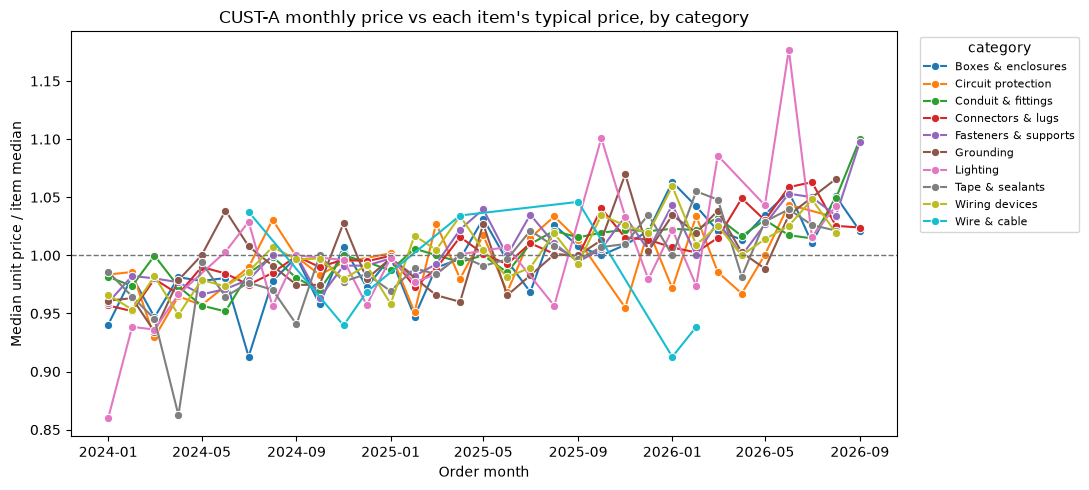

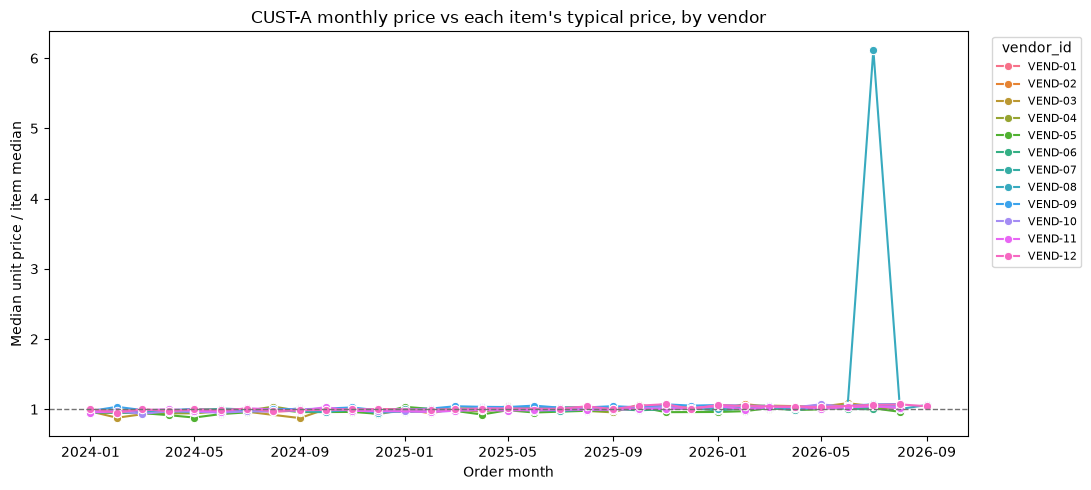

In [18]:
price = df.dropna(subset=["unit_price_paid", "order_date"]).copy()
price["order_month"] = pd.to_datetime(price["order_date"]).dt.to_period("M").dt.to_timestamp()
price["price_vs_item"] = (
    price["unit_price_paid"]
    / price.groupby("item_id")["unit_price_paid"].transform("median")
)

def monthly_median(frame, segment):
    return (
        frame.dropna(subset=[segment])
        .groupby(["order_month", segment], as_index=False)["price_vs_item"]
        .median()
    )

def plot_monthly(monthly, segment, title):
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.lineplot(
        data=monthly, x="order_month", y="price_vs_item",
        hue=segment, marker="o", ax=ax,
    )
    ax.axhline(1.0, color="0.45", lw=1, ls="--")
    ax.set_title(title)
    ax.set_xlabel("Order month")
    ax.set_ylabel("Median unit price / item median")
    ax.legend(title=segment, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()

plot_monthly(monthly_median(price, "category"), "category",
             "CUST-A monthly price vs each item's typical price, by category")
plot_monthly(monthly_median(price, "vendor_id"), "vendor_id",
             "CUST-A monthly price vs each item's typical price, by vendor")

In [19]:
cond = (df["item_id"] == "ITM-0902") & (df["vendor_id"] == "VEND-08")
df[cond][["po_number","order_date", "quantity_ordered", "unit_price_paid", "total_amount", "status"]]

,po_number,order_date,quantity_ordered,unit_price_paid,total_amount,status
582,PO-100134,2025-11-04,1,4.38,9.56,Closed
871,PO-101587,2026-07-01,2,47.00,94.84,Open
1144,PO-101229,2025-03-08,4,4.02,113.72,Received
1147,PO-101275,2024-07-31,1,4.11,363.33,Received
1940,PO-102964,2024-02-24,4,4.20,132.48,Received


In [20]:
df[df["po_number"] == "PO-101587"]

,po_number,item_id,category,unit_of_measure,manufacturer_name,order_date,customer_id,vendor_id,quantity_ordered,unit_price_paid,total_amount,status
419,PO-101587,ITM-0903,Fasteners & supports,EA,Trussmount supports co.,2026-07-01,CUST-A,VEND-08,4,0.21,94.84,Open
871,PO-101587,ITM-0902,Fasteners & supports,BX,Trussmount supports co.,2026-07-01,CUST-A,VEND-08,2,47.00,94.84,Open


In [22]:
conn.sql(
"""
SELECT customer_id,
COUNT(DISTINCT(po_number)) nb_orders
FROM silver.purchase_orders
GROUP BY 1
""")

┌─────────────┬───────────┐
│ customer_id │ nb_orders │
│   varchar   │   int64   │
├─────────────┼───────────┤
│ CUST-A      │       821 │
│ CUST-G      │       144 │
│ CUST-H      │       256 │
│ CUST-D      │       494 │
│ CUST-C      │       276 │
│ CUST-F      │       281 │
│ CUST-B      │       567 │
│ CUST-E      │       161 │
└─────────────┴───────────┘

In [11]:
conn.sql(
"""
SELECT *
FROM gold.item_purchase_history
ORDER BY purchase_frequency DESC
LIMIT 5
""")

┌──────────┬────────────────────┬────────────────────────┬──────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┐
│ item_id  │ purchase_frequency │ earliest_purchase_date │ latest_purchase_date │   price_p25   │   price_p50   │   price_p75   │   price_p90   │
│ varchar  │       int64        │          date          │         date         │ decimal(12,2) │ decimal(12,2) │ decimal(12,2) │ decimal(12,2) │
├──────────┼────────────────────┼────────────────────────┼──────────────────────┼───────────────┼───────────────┼───────────────┼───────────────┤
│ ITM-1015 │                362 │ 2024-01-03             │ 2026-08-29           │          4.22 │          4.37 │          4.54 │          4.66 │
│ ITM-0612 │                327 │ 2024-01-03             │ 2026-09-01           │          3.93 │          4.08 │          4.27 │          4.42 │
│ ITM-0433 │                305 │ 2024-01-09             │ 2026-08-31           │          1.14 │          1.20 │          1

In [6]:
conn.sql(
"""
SELECT *
FROM gold.fct_purchase_order_line
LIMIT 5
""")

┌───────────┬─────────────┬───────────┬────────────┬──────────┬──────────┬──────────────────┬─────────────────┬─────────────────┐
│ po_number │ customer_id │ vendor_id │ order_date │  status  │ item_id  │ quantity_ordered │ unit_price_paid │ extended_amount │
│  varchar  │   varchar   │  varchar  │    date    │ varchar  │ varchar  │      int32       │  decimal(12,2)  │  decimal(18,2)  │
├───────────┼─────────────┼───────────┼────────────┼──────────┼──────────┼──────────────────┼─────────────────┼─────────────────┤
│ PO-101791 │ CUST-B      │ VEND-03   │ 2024-08-06 │ Closed   │ ITM-0618 │                2 │            4.16 │            8.32 │
│ PO-102010 │ CUST-A      │ VEND-05   │ 2025-09-12 │ Received │ ITM-0808 │                4 │            1.75 │            7.00 │
│ PO-101883 │ CUST-C      │ VEND-11   │ 2024-01-17 │ Received │ ITM-0629 │               10 │            2.91 │           29.10 │
│ PO-100395 │ CUST-C      │ VEND-08   │ 2026-04-14 │ Closed   │ ITM-0517 │                

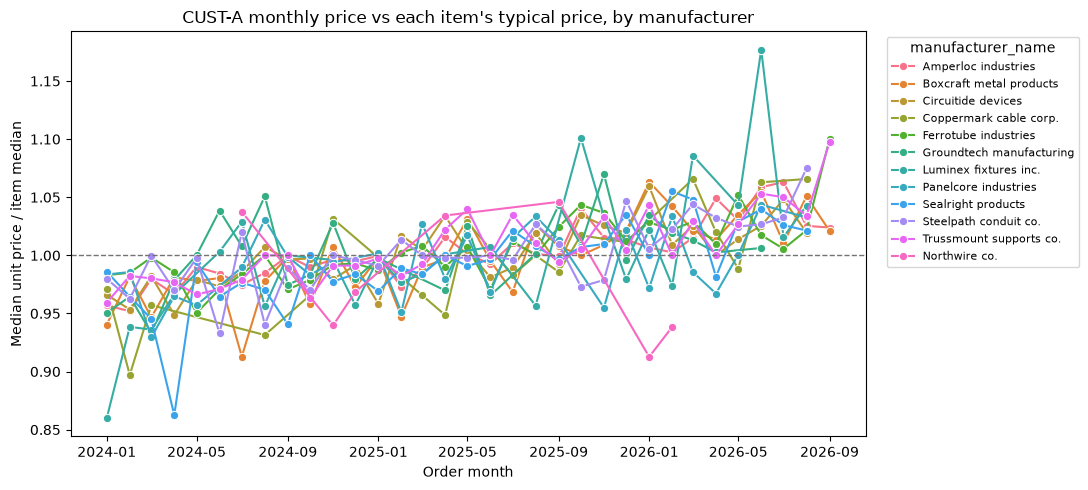

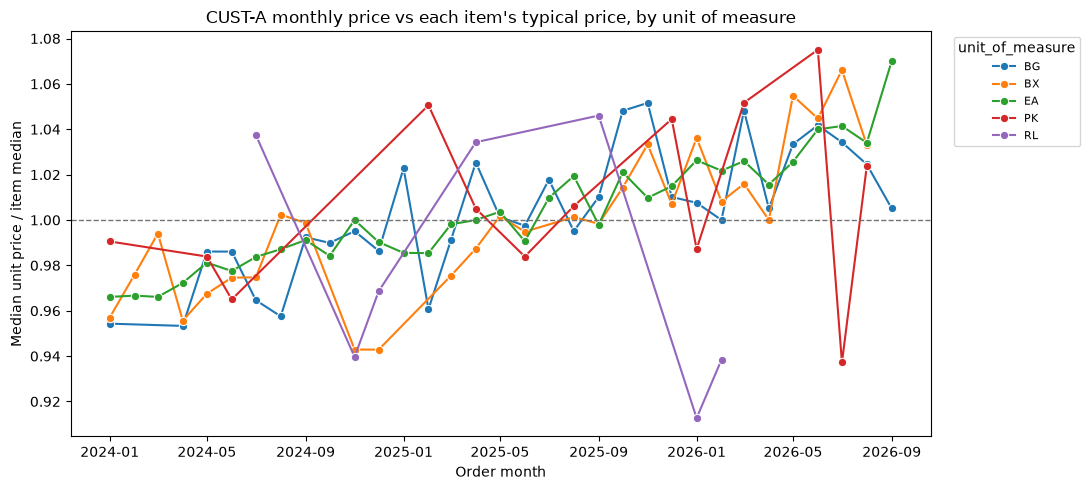

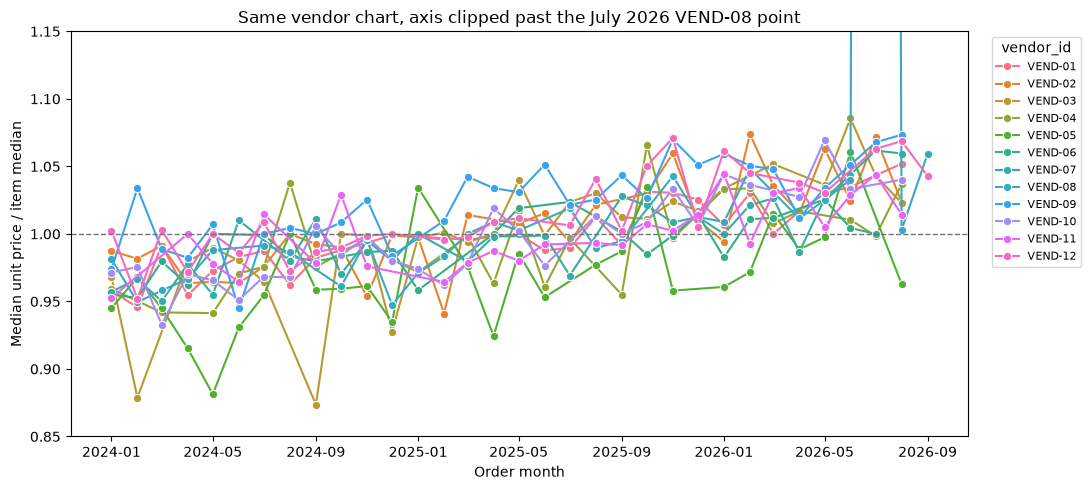

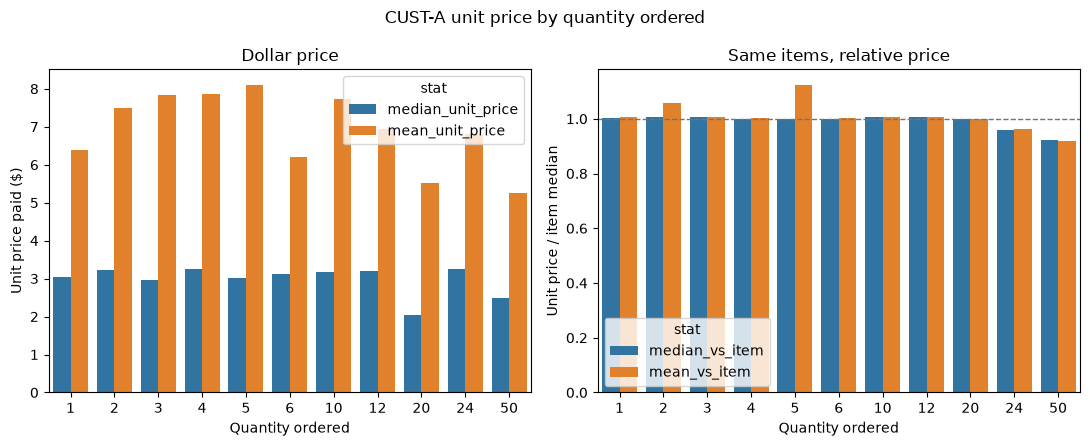

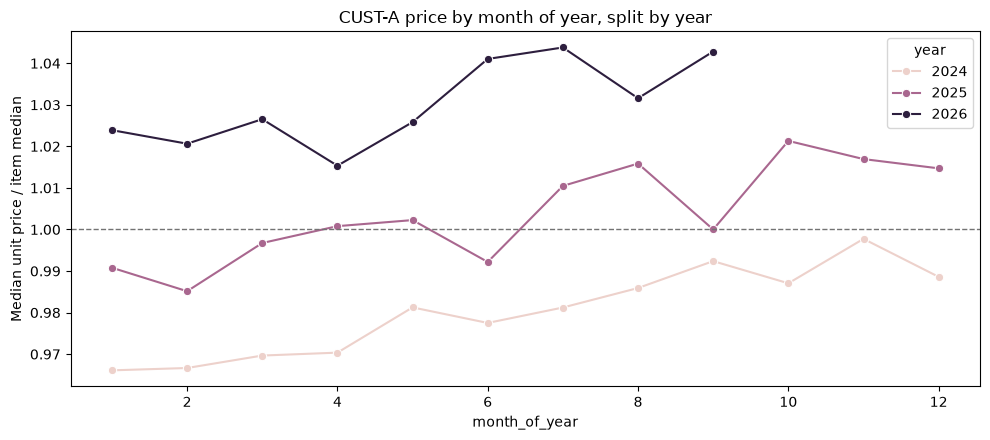

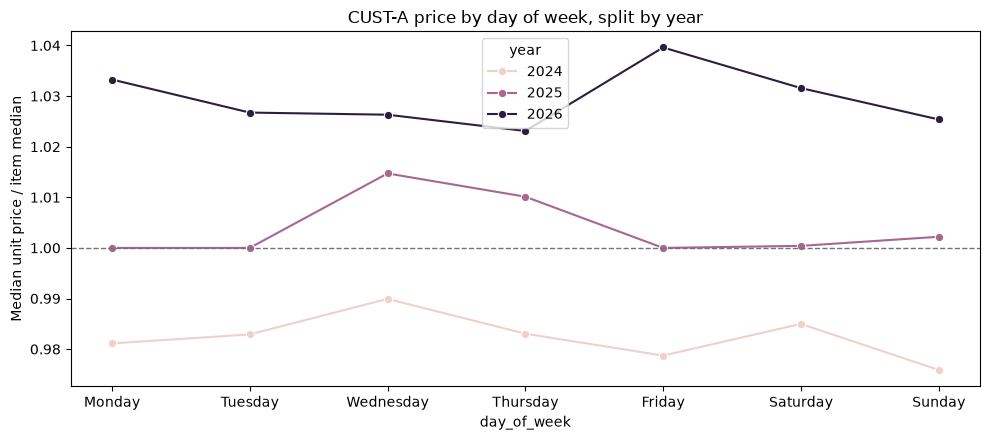

In [23]:
def plot_monthly(monthly, segment, title, ylim=None):
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.lineplot(
        data=monthly, x="order_month", y="price_vs_item",
        hue=segment, marker="o", ax=ax,
    )
    ax.axhline(1.0, color="0.45", lw=1, ls="--")
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_xlabel("Order month")
    ax.set_ylabel("Median unit price / item median")
    ax.legend(title=segment, bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.tight_layout()

plot_monthly(
    monthly_median(price, "manufacturer_name"),
    "manufacturer_name",
    "CUST-A monthly price vs each item's typical price, by manufacturer",
)
plot_monthly(
    monthly_median(price, "unit_of_measure"),
    "unit_of_measure",
    "CUST-A monthly price vs each item's typical price, by unit of measure",
)
plot_monthly(
    monthly_median(price, "vendor_id"),
    "vendor_id",
    "Same vendor chart, axis clipped past the July 2026 VEND-08 point",
    ylim=(0.85, 1.15),
)

qty = (
    price.groupby("quantity_ordered", as_index=False)
    .agg(
        median_unit_price=("unit_price_paid", "median"),
        mean_unit_price=("unit_price_paid", "mean"),
        median_vs_item=("price_vs_item", "median"),
        mean_vs_item=("price_vs_item", "mean"),
        lines=("unit_price_paid", "size"),
    )
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, cols, ylabel, title in [
    (axes[0], ["median_unit_price", "mean_unit_price"], "Unit price paid ($)", "Dollar price"),
    (axes[1], ["median_vs_item", "mean_vs_item"], "Unit price / item median", "Same items, relative price"),
]:
    long = qty.melt(id_vars="quantity_ordered", value_vars=cols, var_name="stat", value_name="value")
    sns.barplot(data=long, x="quantity_ordered", y="value", hue="stat", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Quantity ordered")
    ax.set_ylabel(ylabel)
axes[1].axhline(1.0, color="0.45", lw=1, ls="--")
fig.suptitle("CUST-A unit price by quantity ordered")
fig.tight_layout()

price["year"] = price["order_date"].dt.year
price["month_of_year"] = price["order_date"].dt.month
price["day_of_week"] = pd.Categorical(
    price["order_date"].dt.day_name(),
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True,
)

def plot_calendar(frame, x, title):
    summary = frame.groupby([x, "year"], as_index=False, observed=True)["price_vs_item"].median()
    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.lineplot(data=summary, x=x, y="price_vs_item", hue="year", marker="o", ax=ax)
    ax.axhline(1.0, color="0.45", lw=1, ls="--")
    ax.set_title(title)
    ax.set_ylabel("Median unit price / item median")
    fig.tight_layout()

plot_calendar(price, "month_of_year", "CUST-A price by month of year, split by year")
plot_calendar(price, "day_of_week", "CUST-A price by day of week, split by year")

In [62]:
conn.sql(
"""
SELECT POL.po_number,
POL.customer_id customer_id_purchase_order_line,
PO.customer_id customer_id_purchase_orders,
POL.order_date,
POL.item_id,
POL.unit_price_paid,
PO.total_amount
FROM silver.purchase_orders PO
INNER JOIN gold.fct_purchase_order_line POL
    ON PO.po_number = POL.po_number
    AND PO.customer_id != POL.customer_id
ORDER BY POL.po_number
""")

┌───────────┬─────────────────────────────────┬─────────────────────────────┬────────────┬──────────┬─────────────────┬───────────────┐
│ po_number │ customer_id_purchase_order_line │ customer_id_purchase_orders │ order_date │ item_id  │ unit_price_paid │ total_amount  │
│  varchar  │             varchar             │           varchar           │    date    │ varchar  │  decimal(12,2)  │ decimal(12,2) │
├───────────┼─────────────────────────────────┼─────────────────────────────┼────────────┼──────────┼─────────────────┼───────────────┤
│ PO-100315 │ CUST-C                          │ CUST-G                      │ 2024-03-11 │ ITM-1014 │            2.50 │         51.96 │
│ PO-100402 │ CUST-H                          │ CUST-A                      │ 2025-11-17 │ ITM-0527 │            8.44 │        184.02 │
│ PO-101343 │ CUST-C                          │ CUST-A                      │ 2026-03-24 │ ITM-0610 │            2.23 │         13.38 │
│ PO-101404 │ CUST-G                          │ 

In [ ]:
conn.sql(
"""
SELECT *
FROM silver.itemized_purchase_orders
WHERE po_number = 'PO-100315'
""")

┌───────────┬─────────────┬──────────┬──────────────────┬─────────────────┐
│ po_number │ customer_id │ item_id  │ quantity_ordered │ unit_price_paid │
│  varchar  │   varchar   │ varchar  │      int32       │  decimal(12,2)  │
├───────────┼─────────────┼──────────┼──────────────────┼─────────────────┤
│ PO-100315 │ CUST-G      │ ITM-0610 │               12 │            2.33 │
│ PO-100315 │ CUST-G      │ ITM-0434 │                6 │            1.50 │
│ PO-100315 │ CUST-C      │ ITM-1014 │                6 │            2.50 │
└───────────┴─────────────┴──────────┴──────────────────┴─────────────────┘

In [68]:
conn.sql(
"""
SELECT *
FROM silver.purchase_orders
WHERE po_number = 'PO-100315'
""")

┌───────────┬─────────────┬───────────┬─────────────────────────────┬────────────┬──────────┬───────────────┐
│ po_number │ customer_id │ vendor_id │         vendor_name         │ order_date │  status  │ total_amount  │
│  varchar  │   varchar   │  varchar  │           varchar           │    date    │ varchar  │ decimal(12,2) │
├───────────┼─────────────┼───────────┼─────────────────────────────┼────────────┼──────────┼───────────────┤
│ PO-100315 │ CUST-G      │ VEND-10   │ Ferrowatt Industrial Supply │ 2024-03-11 │ Received │         51.96 │
└───────────┴─────────────┴───────────┴─────────────────────────────┴────────────┴──────────┴───────────────┘

In [70]:
conn.sql(
"""
SELECT *
FROM gold.fct_purchase_order_line
WHERE po_number = 'PO-100315'
""")

┌───────────┬─────────────┬───────────┬────────────┬──────────┬──────────┬──────────────────┬─────────────────┬─────────────────┐
│ po_number │ customer_id │ vendor_id │ order_date │  status  │ item_id  │ quantity_ordered │ unit_price_paid │ extended_amount │
│  varchar  │   varchar   │  varchar  │    date    │ varchar  │ varchar  │      int32       │  decimal(12,2)  │  decimal(18,2)  │
├───────────┼─────────────┼───────────┼────────────┼──────────┼──────────┼──────────────────┼─────────────────┼─────────────────┤
│ PO-100315 │ CUST-G      │ VEND-10   │ 2024-03-11 │ Received │ ITM-0610 │               12 │            2.33 │           27.96 │
│ PO-100315 │ CUST-G      │ VEND-10   │ 2024-03-11 │ Received │ ITM-0434 │                6 │            1.50 │            9.00 │
│ PO-100315 │ CUST-C      │ VEND-10   │ 2024-03-11 │ Received │ ITM-1014 │                6 │            2.50 │           15.00 │
└───────────┴─────────────┴───────────┴────────────┴──────────┴──────────┴────────────────

In [80]:
conn.sql(
"""
SELECT po_number,
item_id,
quantity_ordered,
unit_price_paid,
COUNT(*) AS copies
FROM silver.itemized_purchase_orders
GROUP BY po_number, item_id, quantity_ordered, unit_price_paid
HAVING COUNT(*) > 1
ORDER BY copies DESC, po_number
""")

┌───────────┬──────────┬──────────────────┬─────────────────┬────────┐
│ po_number │ item_id  │ quantity_ordered │ unit_price_paid │ copies │
│  varchar  │ varchar  │      int32       │  decimal(12,2)  │ int64  │
├───────────┼──────────┼──────────────────┼─────────────────┼────────┤
│ PO-100022 │ ITM-0715 │                4 │           80.87 │      2 │
│ PO-100031 │ ITM-0224 │                1 │            1.52 │      2 │
│ PO-100068 │ ITM-1015 │                2 │            4.83 │      2 │
│ PO-100074 │ ITM-0243 │                1 │            0.72 │      2 │
│ PO-100076 │ ITM-0208 │                1 │            5.10 │      2 │
│ PO-100100 │ ITM-0612 │               50 │            3.82 │      2 │
│ PO-100137 │ ITM-0805 │                2 │           32.24 │      2 │
│ PO-100140 │ ITM-0611 │               10 │            3.57 │      2 │
│ PO-100149 │ ITM-1003 │               12 │            1.07 │      2 │
│ PO-100156 │ ITM-0610 │               10 │            2.20 │      2 │
│     

In [82]:
conn.sql(
"""
SELECT *
FROM silver.itemized_purchase_orders
WHERE po_number = 'PO-100022'
""")

┌───────────┬─────────────┬──────────┬──────────────────┬─────────────────┐
│ po_number │ customer_id │ item_id  │ quantity_ordered │ unit_price_paid │
│  varchar  │   varchar   │ varchar  │      int32       │  decimal(12,2)  │
├───────────┼─────────────┼──────────┼──────────────────┼─────────────────┤
│ PO-100022 │ CUST-H      │ ITM-0527 │                6 │            9.43 │
│ PO-100022 │ CUST-H      │ ITM-1001 │                6 │            1.12 │
│ PO-100022 │ CUST-H      │ ITM-0715 │                4 │           80.87 │
│ PO-100022 │ CUST-H      │ ITM-0628 │                1 │            0.16 │
│ PO-100022 │ CUST-H      │ ITM-0921 │                6 │            4.20 │
│ PO-100022 │ CUST-H      │ ITM-0715 │                4 │           80.87 │
│ PO-100022 │ CUST-H      │ ITM-0408 │                3 │            5.43 │
└───────────┴─────────────┴──────────┴──────────────────┴─────────────────┘

In [95]:
conn.sql(
"""
SELECT *
FROM silver.item_pricing
WHERE item_id = 'ITM-0618'
AND vendor_id = 'VEND-12'
ORDER BY price_effective_date ASC
LIMIT 5
""")

┌──────────┬───────────┬──────────────────────┬───────────────┐
│ item_id  │ vendor_id │ price_effective_date │ vendor_price  │
│ varchar  │  varchar  │         date         │ decimal(12,2) │
├──────────┼───────────┼──────────────────────┼───────────────┤
│ ITM-0618 │ VEND-12   │ 2024-01-05           │          4.08 │
│ ITM-0618 │ VEND-12   │ 2024-01-12           │          4.07 │
│ ITM-0618 │ VEND-12   │ 2024-01-19           │          4.09 │
│ ITM-0618 │ VEND-12   │ 2024-01-26           │          4.11 │
│ ITM-0618 │ VEND-12   │ 2024-02-02           │          4.09 │
└──────────┴───────────┴──────────────────────┴───────────────┘

In [94]:
conn.sql(
"""
SELECT PO.po_number,
PO.customer_id,
PO.vendor_id,
PO.order_date,
IPO.unit_price_paid,
IPO.quantity_ordered,
PO.status
FROM silver.purchase_orders PO
INNER JOIN silver.itemized_purchase_orders IPO
    ON PO.po_number = IPO.po_number
WHERE IPO.item_id = 'ITM-0618'
AND PO.vendor_id = 'VEND-12'
ORDER BY PO.order_date ASC
""")

┌───────────┬─────────────┬───────────┬────────────┬─────────────────┬──────────────────┬───────────┐
│ po_number │ customer_id │ vendor_id │ order_date │ unit_price_paid │ quantity_ordered │  status   │
│  varchar  │   varchar   │  varchar  │    date    │  decimal(12,2)  │      int32       │  varchar  │
├───────────┼─────────────┼───────────┼────────────┼─────────────────┼──────────────────┼───────────┤
│ PO-102768 │ CUST-C      │ VEND-12   │ 2024-01-21 │            4.06 │                4 │ Closed    │
│ PO-101892 │ CUST-C      │ VEND-12   │ 2024-03-10 │            4.13 │               12 │ Received  │
│ PO-101408 │ CUST-A      │ VEND-12   │ 2024-04-20 │            3.89 │                1 │ Received  │
│ PO-100138 │ CUST-A      │ VEND-12   │ 2024-05-23 │            3.59 │               24 │ Received  │
│ PO-101090 │ CUST-A      │ VEND-12   │ 2024-06-08 │            3.62 │               10 │ Closed    │
│ PO-100813 │ CUST-D      │ VEND-12   │ 2024-06-30 │            4.06 │            

In [96]:
conn.sql(
"""
WITH list_price AS (
    SELECT item_id,
           vendor_id,
           price_effective_date,
           avg(vendor_price) AS vendor_price
    FROM silver.item_pricing
    GROUP BY 1, 2, 3
),
lines AS (
    SELECT DISTINCT po_number, item_id, quantity_ordered, unit_price_paid
    FROM silver.itemized_purchase_orders
),
purchases AS (
    SELECT l.po_number,
           po.order_date,
           po.vendor_id,
           l.item_id,
           l.unit_price_paid
    FROM lines l
    INNER JOIN silver.purchase_orders po
        ON po.po_number = l.po_number
    WHERE po.customer_id = 'CUST-A'
      AND l.unit_price_paid IS NOT NULL
)
SELECT count(*) AS lines,
       count(lp.vendor_price) AS with_list_price,
       count(*) FILTER (WHERE p.unit_price_paid = lp.vendor_price) AS exact_match,
       median(p.unit_price_paid / lp.vendor_price) AS median_paid_over_list
FROM purchases p
ASOF LEFT JOIN list_price lp
    ON p.item_id = lp.item_id
   AND p.vendor_id = lp.vendor_id
   AND p.order_date >= lp.price_effective_date
""")

┌───────┬─────────────────┬─────────────┬───────────────────────┐
│ lines │ with_list_price │ exact_match │ median_paid_over_list │
│ int64 │      int64      │    int64    │        double         │
├───────┼─────────────────┼─────────────┼───────────────────────┤
│  2259 │            2250 │          31 │    0.9385408824966651 │
└───────┴─────────────────┴─────────────┴───────────────────────┘

In [5]:
conn.sql(
"""
WITH LINES AS (
    SELECT DISTINCT po_number, item_id, quantity_ordered, unit_price_paid
    FROM silver.itemized_purchase_orders
),
LINE_TOTALS AS (
    SELECT po_number,
    SUM(quantity_ordered * unit_price_paid) AS lines_total_amount
    FROM LINES
    GROUP BY 1
),
DIFFERENCES AS (
    SELECT PO.po_number,
    PO.customer_id,
    PO.order_date,
    PO.total_amount,
    L.lines_total_amount,
    PO.total_amount - L.lines_total_amount AS amount_diff
    FROM silver.purchase_orders PO
    INNER JOIN LINE_TOTALS L
        ON PO.po_number = L.po_number
)
SELECT *
FROM DIFFERENCES
WHERE ABS(amount_diff) > 0
""")

┌───────────┬─────────────┬────────────┬───────────────┬────────────────────┬───────────────┐
│ po_number │ customer_id │ order_date │ total_amount  │ lines_total_amount │  amount_diff  │
│  varchar  │   varchar   │    date    │ decimal(12,2) │   decimal(38,2)    │ decimal(38,2) │
├───────────┼─────────────┼────────────┼───────────────┼────────────────────┼───────────────┤
│ PO-101829 │ CUST-B      │ 2024-05-23 │         18.86 │             130.92 │       -112.06 │
│ PO-103117 │ CUST-E      │ 2024-04-06 │          4.66 │              57.98 │        -53.32 │
│ PO-100071 │ CUST-H      │ 2025-07-31 │        208.19 │             275.61 │        -67.42 │
│ PO-103098 │ CUST-D      │ 2026-05-11 │         73.63 │              52.63 │         21.00 │
│ PO-100128 │ CUST-F      │ 2026-06-06 │         66.83 │              65.60 │          1.23 │
│ PO-103154 │ CUST-E      │ 2025-07-17 │         92.60 │             308.52 │       -215.92 │
│ PO-101231 │ CUST-D      │ 2026-03-27 │         42.69 │    

In [6]:
conn.sql(
"""
WITH LINES AS (
    SELECT DISTINCT po_number, item_id, quantity_ordered, unit_price_paid
    FROM silver.itemized_purchase_orders
)
SELECT *
FROM LINES
WHERE po_number = 'PO-101829'
"""
)

┌───────────┬──────────┬──────────────────┬─────────────────┐
│ po_number │ item_id  │ quantity_ordered │ unit_price_paid │
│  varchar  │ varchar  │      int32       │  decimal(12,2)  │
├───────────┼──────────┼──────────────────┼─────────────────┤
│ PO-101829 │ ITM-0239 │                2 │           56.03 │
│ PO-101829 │ ITM-0404 │                4 │            3.20 │
│ PO-101829 │ ITM-0412 │                6 │            1.01 │
└───────────┴──────────┴──────────────────┴─────────────────┘

In [18]:
conn.sql(
"""
SELECT *
FROM silver.item_pricing
WHERE item_id = 'ITM-0305'
""")

┌─────────┬───────────┬──────────────────────┬───────────────┐
│ item_id │ vendor_id │ price_effective_date │ vendor_price  │
│ varchar │  varchar  │         date         │ decimal(12,2) │
└─────────┴───────────┴──────────────────────┴───────────────┘
                            0 rows                          

In [19]:
41.17 * 2

82.34

In [15]:
conn.sql(
"""
WITH LINES AS (
    SELECT DISTINCT po_number, item_id, quantity_ordered, unit_price_paid
    FROM silver.itemized_purchase_orders
)
SELECT *
FROM LINES
WHERE po_number = 'PO-101349'
"""
)

┌───────────┬──────────┬──────────────────┬─────────────────┐
│ po_number │ item_id  │ quantity_ordered │ unit_price_paid │
│  varchar  │ varchar  │      int32       │  decimal(12,2)  │
├───────────┼──────────┼──────────────────┼─────────────────┤
│ PO-101349 │ ITM-0612 │                2 │            3.97 │
│ PO-101349 │ ITM-0715 │                2 │           70.31 │
│ PO-101349 │ ITM-0251 │                2 │            2.31 │
│ PO-101349 │ ITM-0305 │                2 │           41.17 │
└───────────┴──────────┴──────────────────┴─────────────────┘

In [17]:
conn.sql(
"""
WITH LINES AS (
    SELECT DISTINCT po_number, item_id, quantity_ordered, unit_price_paid
    FROM silver.itemized_purchase_orders
)
SELECT *
FROM LINES
WHERE item_id = 'ITM-0305'
"""
)

┌───────────┬──────────┬──────────────────┬─────────────────┐
│ po_number │ item_id  │ quantity_ordered │ unit_price_paid │
│  varchar  │ varchar  │      int32       │  decimal(12,2)  │
├───────────┼──────────┼──────────────────┼─────────────────┤
│ PO-101349 │ ITM-0305 │                2 │           41.17 │
└───────────┴──────────┴──────────────────┴─────────────────┘

In [ ]:
# These are items that are not in the item_pricing table, appeared only once in history and header was computed
# as if the item was not on the order, I'll set these aside 

conn.sql(
"""
WITH lines AS (
    SELECT DISTINCT po_number, item_id, quantity_ordered, unit_price_paid
    FROM silver.itemized_purchase_orders
    WHERE unit_price_paid IS NOT NULL
),
line_totals AS (
    SELECT po_number,
           sum(quantity_ordered * unit_price_paid) AS lines_total_amount
    FROM lines
    GROUP BY 1
),
gaps AS (
    SELECT po.po_number,
           po.customer_id,
           lt.lines_total_amount - po.total_amount AS gap
    FROM silver.purchase_orders po
    INNER JOIN line_totals lt USING (po_number)
    WHERE abs(lt.lines_total_amount - po.total_amount) > 0.02
),
once AS (
    SELECT item_id
    FROM lines
    GROUP BY 1
    HAVING count(*) = 1
)
SELECT g.po_number,
       g.customer_id,
       l.item_id,
       l.quantity_ordered,
       l.unit_price_paid,
       l.quantity_ordered * l.unit_price_paid AS extended_amount,
       g.gap
FROM gaps g
INNER JOIN lines l
    ON l.po_number = g.po_number
   AND abs(l.quantity_ordered * l.unit_price_paid - g.gap) <= 0.02
INNER JOIN once USING (item_id)
WHERE l.item_id NOT IN (SELECT DISTINCT item_id FROM silver.item_pricing)
ORDER BY g.po_number
""")

┌───────────┬─────────────┬──────────┬──────────────────┬─────────────────┬─────────────────┬───────────────┐
│ po_number │ customer_id │ item_id  │ quantity_ordered │ unit_price_paid │ extended_amount │      gap      │
│  varchar  │   varchar   │ varchar  │      int32       │  decimal(12,2)  │  decimal(18,2)  │ decimal(38,2) │
├───────────┼─────────────┼──────────┼──────────────────┼─────────────────┼─────────────────┼───────────────┤
│ PO-100071 │ CUST-H      │ ITM-0822 │                2 │           33.71 │           67.42 │         67.42 │
│ PO-100857 │ CUST-A      │ ITM-0240 │                4 │           44.09 │          176.36 │        176.36 │
│ PO-101198 │ CUST-C      │ ITM-0116 │                1 │           20.42 │           20.42 │         20.42 │
│ PO-101349 │ CUST-A      │ ITM-0305 │                2 │           41.17 │           82.34 │         82.34 │
│ PO-101807 │ CUST-C      │ ITM-1002 │                6 │           17.28 │          103.68 │        103.68 │
│ PO-10182

In [2]:
conn.sql(
"""
WITH LINES AS (
    SELECT po_number,
    SUM(quantity_ordered * unit_price_paid) AS lines_total_amount
    FROM silver.itemized_purchase_orders
    GROUP BY 1
),
DIFFERENCES AS (
    SELECT PO.po_number,
    PO.customer_id,
    PO.order_date,
    PO.total_amount,
    L.lines_total_amount,
    PO.total_amount - L.lines_total_amount AS amount_diff
    FROM silver.purchase_orders PO
    INNER JOIN LINES L
        ON PO.po_number = L.po_number
)
SELECT AVG(amount_diff) AS avg_diff,
MEDIAN(amount_diff) AS median_diff,
MAX(ABS(amount_diff)) AS max_diff,
MIN(ABS(amount_diff)) AS min_diff,
AVG(CAST(amount_diff > 0 AS INT)) header_higher_than_lines_ratio
FROM DIFFERENCES
WHERE ABS(amount_diff) > 0
""")

┌───────────────────┬───────────────┬───────────────┬───────────────┬────────────────────────────────┐
│     avg_diff      │  median_diff  │   max_diff    │   min_diff    │ header_higher_than_lines_ratio │
│      double       │ decimal(38,2) │ decimal(38,2) │ decimal(38,2) │             double             │
├───────────────────┼───────────────┼───────────────┼───────────────┼────────────────────────────────┤
│ -59.4055497382199 │        -14.04 │        943.68 │          0.42 │            0.09947643979057591 │
└───────────────────┴───────────────┴───────────────┴───────────────┴────────────────────────────────┘

In [98]:
conn.sql(
"""
SELECT *
FROM silver.purchase_orders
WHERE po_number = 'PO-102016'
""")


┌───────────┬─────────────┬───────────┬──────────────────────────────┬────────────┬─────────┬───────────────┐
│ po_number │ customer_id │ vendor_id │         vendor_name          │ order_date │ status  │ total_amount  │
│  varchar  │   varchar   │  varchar  │           varchar            │    date    │ varchar │ decimal(12,2) │
├───────────┼─────────────┼───────────┼──────────────────────────────┼────────────┼─────────┼───────────────┤
│ PO-102016 │ CUST-A      │ VEND-07   │ BrightPath Electrical Supply │ 2026-01-29 │ Closed  │        339.32 │
└───────────┴─────────────┴───────────┴──────────────────────────────┴────────────┴─────────┴───────────────┘

In [ ]:
# Insights so far

## Data inconsistencies and errors:

# There's inconsistencies between headers and lines on customer_ids. I'll assume that headers are correct.
# Silver lines table has duplicates. I'll drop them and make the fix on gold too.
# There's items that are not in the item_pricing table, appeared only once in history and header was computed
# as if the item was not on the order, I'll set these aside 

## Insights

# Customers don't seem to be paying list price. At least for CUST-A, they are paying around 6% off list price.
# ITM-0902 has multiple and significant price jumps
# There is no seasonal month or weekday with apparent best prices
# CUST-A Get's better prices than other customers: On the same item, the same vendor, and the same month, A's median paid price is 0.94 times the other customers' median (858 overlapping cells; the middle half sits between 0.92 and 0.97). 
# Prices are slowly increasing over time
# It doesn't look like there's a relationship between quantity ordered and price paid (no volume discounts)

